<a href="https://colab.research.google.com/github/AdiRatnam/Hands_on_Pytorch/blob/main/MNIST_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

In [2]:
#device config, later we need to push our tensor to the device , to allow it to run on gpu if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [3]:
# HyperParameters
input_size = 784 # 28x28 image size
hidden_size = 500
num_classes = 10
num_epochs = 2
batch_size = 100
learning_rate = 0.001

In [10]:
# MNIST dataset
train_dataset = torchvision.datasets.MNIST(root='./data',
                                           train=True,
                                           transform=transforms.ToTensor(),
                                           download=True)

test_dataset = torchvision.datasets.MNIST(root='./data',
                                          train=False,
                                          transform=transforms.ToTensor())

In [11]:
# Data loader
train_loader = torch.utils.data.DataLoader(dataset=train_dataset,
                                           batch_size=batch_size,
                                           shuffle=True)

test_loader = torch.utils.data.DataLoader(dataset=test_dataset,
                                          batch_size=batch_size,
                                          shuffle=False)

In [14]:
examples = iter(train_loader)
samples, labels = next(examples)
print(samples.shape, labels.shape)

torch.Size([100, 1, 28, 28]) torch.Size([100])


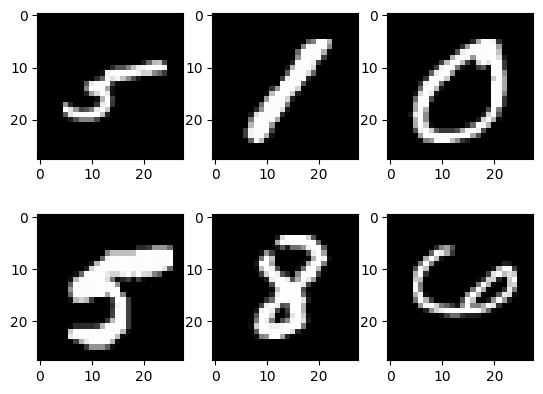

In [17]:
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(samples[i][0], cmap='gray')
plt.show()

In [18]:
#create a neural network class
class NeuralNet(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(NeuralNet, self).__init__()
        # set the layers
        self.l1 = nn.Linear(input_size, hidden_size) # 1st layer
        self.relu = nn.ReLU() # applying activation function
        self.l2 = nn.Linear(hidden_size, num_classes) # 2nd layer

    # forward prop
    def forward(self, x):
        out = self.l1(x)
        out = self.relu(out)
        out = self.l2(out)
        # no activation and no softmax at the end
        return out

# final model
model = NeuralNet(input_size, hidden_size, num_classes)


In [20]:
# loss and optimizer
criterion  = nn.CrossEntropyLoss()
optimizer  = torch.optim.Adam(model.parameters(), lr=learning_rate)


In [22]:
# Training loop

n_total_steps = len(train_loader)
for epoch in range(num_epochs):
    for i, (images, labels) in enumerate(train_loader):
      # need to reshape image
      # our shape 100,1,28,28
      #we need 100,784
      # image is - 784, so we need to reshape our tensor
      images = images.reshape(-1, 28*28).to(device) # -1 cuz it will find automatically
      labels = labels.to(device)

      # Forward pass
      outputs = model(images)
      loss = criterion(outputs, labels)

      # Backward pass
      optimizer.zero_grad() # enpty the value of gradient
      loss.backward() # backpropogation
      optimizer.step() #update the parameter

      if (i+1) % 100 == 0:
          print (f'Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{n_total_steps}], Loss: {loss.item():.4f}')



Epoch [1/2], Step [100/600], Loss: 0.2898
Epoch [1/2], Step [200/600], Loss: 0.3767
Epoch [1/2], Step [300/600], Loss: 0.2427
Epoch [1/2], Step [400/600], Loss: 0.2052
Epoch [1/2], Step [500/600], Loss: 0.1799
Epoch [1/2], Step [600/600], Loss: 0.1536
Epoch [2/2], Step [100/600], Loss: 0.1402
Epoch [2/2], Step [200/600], Loss: 0.1728
Epoch [2/2], Step [300/600], Loss: 0.2219
Epoch [2/2], Step [400/600], Loss: 0.1265
Epoch [2/2], Step [500/600], Loss: 0.0912
Epoch [2/2], Step [600/600], Loss: 0.0438


In [23]:
# testing or evaluation
with torch.no_grad():  # since we do not want to compute gradient here
  # since no of correct prediction and sample is 0 in the brgining
  n_correct = 0
  n_samples = 0

  for images, labels in test_loader:
    images = images.reshape(-1, 28*28).to(device) #reshape again
    labels = labels.to(device)
    outputs = model(images)

    # torch.max will return th value, index but we only need index
    _, predictions = torch.max(outputs, 1)
    n_samples += labels.shape[0] # provides no. of samples in current batch
    n_correct += (predictions == labels).sum().item() # inc correct value of matched with correct label

  acc = 100.0 * n_correct / n_samples
  print(f'accuracy = {acc}')



accuracy = 96.88
